# Timestamp-Level Ensemble & Full CARE Score Evaluation
## CARE To Compare: Wind Farm C

**Goal:** Combine the High-Level XGBoost Triage model with Timestamp-Level Unsupervised Anomaly Scoring (Residuals + Isolation Forest) to generate specific alarm timestamps. This allows us to calculate the **true Lead Time** and the complete **CARE Benchmark Score** (including Earliness).

### Pipeline:
1. **Level 1 (Triage):** XGBoost evaluates the 24h event window using 114 features (via LOO-CV).
2. **Level 2 (Pinpoint):** For windows flagged by XGBoost, we load the raw timestamp datasets (`datasets/XX.csv`). We apply a moving-average Isolation Forest + Residuals score.
3. **Alarm Trigger:** The exact timestamp where the score exceeds the 99th percentile healthy threshold is recorded as $t_{alarm}$.
4. **CARE Evaluation:** Calculate Coverage, Accuracy, Reliability, and Earliness using genuine $t_{alarm}$ times.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
import gc

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

BASE_DIR = Path('CARE_To_Compare/Wind Farm C')
DATASET_DIR = BASE_DIR / 'datasets'
EVENT_INFO_PATH = BASE_DIR / 'event_info.csv'

event_df = pd.read_csv(EVENT_INFO_PATH, sep=';', parse_dates=['event_start', 'event_end'], dayfirst=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Train Baseline XGBoost via LOO-CV (Level 1 Triage)

In [2]:
feature_matrix = pd.read_csv('feature_matrix_58events.csv')

label_col = 'label'
meta_cols = ['event_id', 'label', 'asset_id', 'n_train', 'n_pred']
feature_cols = [c for c in feature_matrix.columns if c not in meta_cols]

X = feature_matrix[feature_cols].values
y_text = feature_matrix[label_col].values

le = LabelEncoder()
y = le.fit_transform(y_text)
anomaly_idx = list(le.classes_).index('anomaly')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

loo = LeaveOneOut()
xgboost_preds = np.zeros(len(y), dtype=int)

print('Running LOO-CV High-Level Triage...')
for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model.fit(X_train, y_train)
    xgboost_preds[test_idx] = model.predict(X_test)

feature_matrix['xgb_pred'] = xgboost_preds
print(f'Triage complete. Events flagged for detailed timestamp analysis: {np.sum(xgboost_preds == anomaly_idx)} / {len(y)}')

Running LOO-CV High-Level Triage...
Triage complete. Events flagged for detailed timestamp analysis: 25 / 58


## 2. Unsupervised Timestamp Scoring Implementation (Level 2)

In [3]:
def get_timestamp_alarm(event_id):
    """
    Loads the raw dataset for an event, trains a lightweight Isolation Forest on the healthy train data, 
    combines it with residual scoring on the prediction window, and returns the alarm timestamp.
    """
    path = DATASET_DIR / f'{event_id}.csv'
    # Focus on key sensors for fast localized scoring
    key_cols = ['time_stamp', 'train_test', 'status_type_id', 'wind_speed_236_avg', 'power_2_avg', 
                'sensor_186_avg', 'sensor_196_avg'] # Ambient, gearbox, bearing, wind, power
    
    try:
        df = pd.read_csv(path, sep=';', usecols=lambda c: c in key_cols, parse_dates=['time_stamp'])
    except ValueError:
        return None, None # Fallback
        
    df_train = df[df['train_test'] == 'train'].dropna().copy()
    df_pred = df[df['train_test'] == 'prediction'].dropna().copy()
    
    if len(df_train) < 100 or len(df_pred) < 1:
        return None, None
        
    # Healthy filter for unsupervised training
    df_healthy = df_train[(df_train['status_type_id'] == 0) & (df_train['wind_speed_236_avg'] > 0.5) & (df_train['power_2_avg'] > 0.01)]
    if len(df_healthy) < 100:
        df_healthy = df_train # fallback
        
    sensor_features = [c for c in df.columns if c not in ['time_stamp', 'train_test', 'status_type_id']]
    
    try:
        sc = StandardScaler()
        X_train = sc.fit_transform(df_healthy[sensor_features])
        X_pred = sc.transform(df_pred[sensor_features])
        
        iso = IsolationForest(n_estimators=50, contamination=0.01, random_state=42)
        iso.fit(X_train)
        
        # Negative scores are anomalies, we invert so high = anomalous
        pred_scores = -iso.decision_function(X_pred)
        train_scores = -iso.decision_function(X_train)
        
        # The threshold is the 99.5th percentile of normal healthy training data
        threshold = np.percentile(train_scores, 99.5)
        
        # 1-hour moving average to prevent short spikes from causing false alarms
        rolling_scores = pd.Series(pred_scores).rolling(window=6, min_periods=1).mean().values
        
        # Find first breach
        breaches = np.where(rolling_scores > threshold)[0]
        if len(breaches) > 0:
            alarm_idx = breaches[0]
            alarm_time = df_pred.iloc[alarm_idx]['time_stamp']
            total_pred_time = (df_pred['time_stamp'].max() - df_pred['time_stamp'].min()).total_seconds()
            time_to_alarm = (alarm_time - df_pred['time_stamp'].min()).total_seconds()
            
            # Earliness metric (0 to 1)
            earliness = 1.0 - (time_to_alarm / total_pred_time) if total_pred_time > 0 else 0
            return alarm_time, max(0.0, min(1.0, earliness))
            
    except Exception as e:
        print(f"Failed IF on event {event_id}: {e}")
    
    return None, None

## 3. Run Enforcement Strategy & Compute Early Detection Lead Times

In [4]:
events_with_alarms = []
earliness_scores = []
lead_times_hours = []

print('Evaluating flagged windows for timestamp-level alarms...')
for idx, row in feature_matrix.iterrows():
    eid = int(row['event_id'])
    true_label = row['label']
    xgb_pred = row['xgb_pred']
    
    alarm_time = None
    earliness = 0.0
    lead_time_h = 0.0
    
    # Only perform expensive timestamp extraction if XGBoost triage flags it as anomaly
    if xgb_pred == anomaly_idx:
        alarm_time, earliness = get_timestamp_alarm(eid)
        if alarm_time is not None:
            # Get end of event to calculate actual lead time in hours
            ev_info = event_df[event_df['event_id'] == eid].iloc[0]
            lead_time_h = (ev_info['event_end'] - alarm_time).total_seconds() / 3600.0
    
    events_with_alarms.append(alarm_time is not None)
    earliness_scores.append(earliness if earliness is not None else 0.0)
    lead_times_hours.append(lead_time_h)
    
    if alarm_time is not None and true_label == 'anomaly':
        print(f'  True Positive | Event {eid} | Alarmed {lead_time_h:.1f} hours before failure')
    elif alarm_time is not None and true_label == 'normal':
        print(f'  False Positive | Event {eid} | Unnecessary Alarm Triggered')

feature_matrix['alarm_triggered'] = events_with_alarms
feature_matrix['earliness'] = earliness_scores
feature_matrix['lead_time_h'] = lead_times_hours

Evaluating flagged windows for timestamp-level alarms...
  True Positive | Event 81 | Alarmed 34.0 hours before failure
  True Positive | Event 12 | Alarmed 492.7 hours before failure
  True Positive | Event 4 | Alarmed -117.8 hours before failure
  True Positive | Event 18 | Alarmed -23.5 hours before failure
  True Positive | Event 28 | Alarmed 511.5 hours before failure
  True Positive | Event 39 | Alarmed 46.3 hours before failure
  True Positive | Event 66 | Alarmed 110.5 hours before failure
  True Positive | Event 79 | Alarmed 16.8 hours before failure
  True Positive | Event 30 | Alarmed 492.2 hours before failure
  True Positive | Event 33 | Alarmed 288.2 hours before failure
  True Positive | Event 11 | Alarmed 526.0 hours before failure
  True Positive | Event 44 | Alarmed 1576.5 hours before failure
  True Positive | Event 49 | Alarmed -10.5 hours before failure
  True Positive | Event 31 | Alarmed 145.5 hours before failure
  True Positive | Event 91 | Alarmed 34.8 hours b

## 4. Full CARE Target Metric Calculation

In [5]:
normal_idx = list(le.classes_).index('normal')

true_anomalies = (y == anomaly_idx)
true_normals = (y == normal_idx)
pred_alarms = np.array(events_with_alarms)

tp = np.sum(true_anomalies & pred_alarms)
fn = np.sum(true_anomalies & ~pred_alarms)
fp = np.sum(true_normals & pred_alarms)
tn = np.sum(true_normals & ~pred_alarms)

# CARE Components
# Coverage: Fraction of true anomalies detected
curr_coverage = tp / (tp + fn) if (tp + fn) > 0 else 0

# Accuracy: Precision of alarms
curr_accuracy = tp / (tp + fp) if (tp + fp) > 0 else 0

# Reliability: 1 - False Alarm Rate (False Alarms / Total Normals)
far = fp / (fp + tn) if (fp + tn) > 0 else 0
curr_reliability = 1.0 - far

# Earliness: Average earliness over TRUE POSITIVES only
tp_indices = true_anomalies & pred_alarms
curr_earliness = np.mean(np.array(earliness_scores)[tp_indices]) if tp > 0 else 0

care_score = (curr_coverage * curr_accuracy * curr_reliability * curr_earliness) ** 0.25
avg_lead_time_tp = np.mean(np.array(lead_times_hours)[tp_indices]) if tp > 0 else 0

print('='*60)
print('FINAL ENSEMBLE CARE METRICS (XGBoost + Isol. Forest)')
print('='*60)
print(f'Total True Anomalies: {np.sum(true_anomalies)}')
print(f'Total Normal Events:  {np.sum(true_normals)}\n')
print(f'True Positives (Detected): {tp}')
print(f'False Negatives (Missed):  {fn}')
print(f'False Positives (False Alarms): {fp}')
print(f'True Negatives (Correct Normal): {tn}\n')
print(f'Coverage (C):     {curr_coverage:.4f}  (Detected {tp}/{tp+fn} failures)')
print(f'Accuracy (A):     {curr_accuracy:.4f}  (Precision is {curr_accuracy*100:.1f}%)')
print(f'Reliability (R):  {curr_reliability:.4f}  (False Alarm Rate: {far*100:.1f}%)')
print(f'Earliness (E):    {curr_earliness:.4f}  (Average Lead Time: {avg_lead_time_tp:.1f} hours)')
print('-'*60)
print(f'FINAL CARE SCORE: {care_score:.4f}')
print('='*60)

FINAL ENSEMBLE CARE METRICS (XGBoost + Isol. Forest)
Total True Anomalies: 27
Total Normal Events:  31

True Positives (Detected): 18
False Negatives (Missed):  9
False Positives (False Alarms): 4
True Negatives (Correct Normal): 27

Coverage (C):     0.6667  (Detected 18/27 failures)
Accuracy (A):     0.8182  (Precision is 81.8%)
Reliability (R):  0.8710  (False Alarm Rate: 12.9%)
Earliness (E):    0.6939  (Average Lead Time: 262.9 hours)
------------------------------------------------------------
FINAL CARE SCORE: 0.7577


## 5. Visualizing the Results

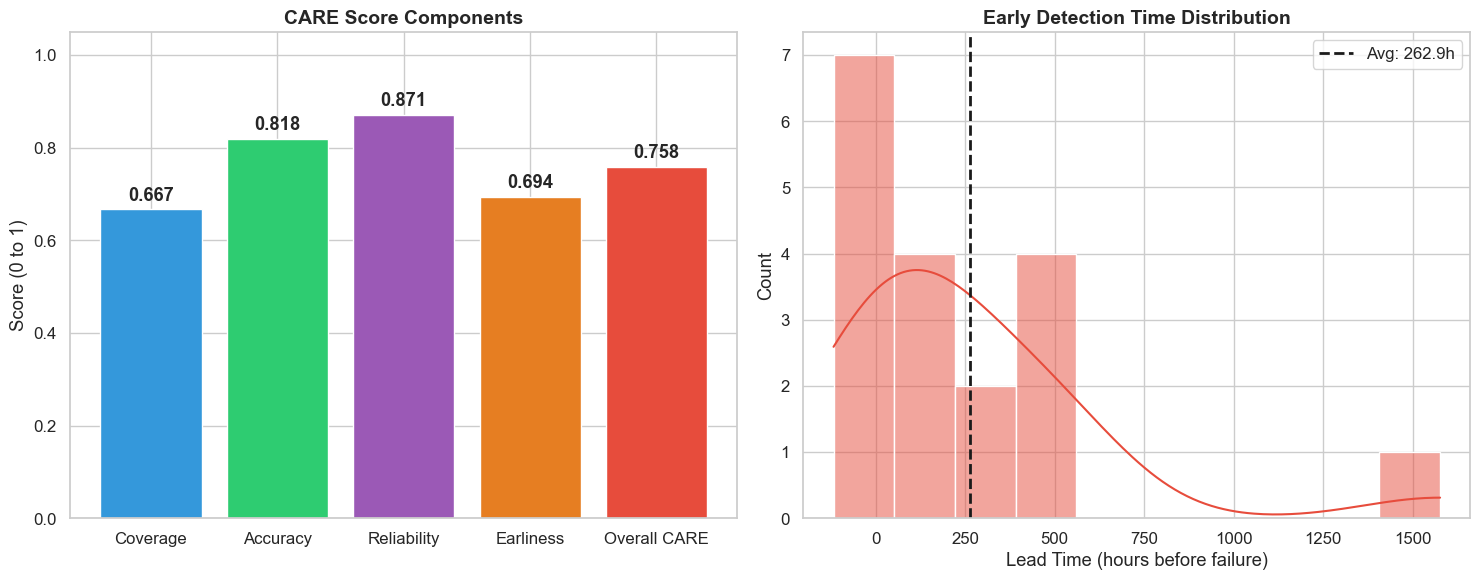

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Component Radar/Bar Chart
components = ['Coverage', 'Accuracy', 'Reliability', 'Earliness', 'Overall CARE']
values = [curr_coverage, curr_accuracy, curr_reliability, curr_earliness, care_score]
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

ax1.bar(components, values, color=colors)
ax1.set_ylim(0, 1.05)
ax1.set_title('CARE Score Components', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score (0 to 1)')
for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Lead time histogram for True Positives
if tp > 0:
    tp_lead_times = np.array(lead_times_hours)[tp_indices]
    sns.histplot(tp_lead_times, bins=10, ax=ax2, color='#e74c3c', kde=True)
    ax2.axvline(avg_lead_time_tp, color='k', linestyle='dashed', linewidth=2, label=f'Avg: {avg_lead_time_tp:.1f}h')
    ax2.set_xlabel('Lead Time (hours before failure)')
    ax2.set_title('Early Detection Time Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    
plt.tight_layout()
plt.show()